# News Topic Classification

Classify English news articles into four topics — **World, Sports, Business, Sci/Tech** —
from their title and description.

**Pipeline:** clean text → explore → TF-IDF features → compare 3 classic models →
a neural network → honest evaluation → interpret.

Reusable logic lives in [`src/`](../src); this notebook is the narrative that ties it together.

## 0 · Setup

In [1]:
import os
# Windows + conda 的 OpenMP 冲突的标准 workaround，放在所有 import 之前最稳。
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import sys, warnings
from pathlib import Path

# 定位项目根目录（含 src/ 的那层），无论从哪里启动 notebook 都能找到
ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
DATA = ROOT / "data" / "ag_news.csv"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from preprocess import load_data
from features import build_features, split_data
from train import train_and_evaluate, best_model, evaluate_model

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

## 1 · Load & clean the data

`load_data` reads the CSV, drops nulls/duplicates, cleans **both** *Title* and *Description*
(decode HTML entities → lowercase → keep letters → drop stopwords / HTML-junk / single chars),
and fuses them into a single `text` column.

In [2]:
df = load_data(DATA)
print(f"{len(df)} articles after cleaning")
df[["category", "Title", "text"]].head()

7600 articles after cleaning


,category,Title,text
0,Business,Fears for T N pension after talks,fears pension talks unions representing worker...
1,Sci/Tech,The Race is On: Second Private Team Sets Launc...,race second private team sets launch date huma...
2,Sci/Tech,Ky. Company Wins Grant to Study Peptides (AP),ky company wins grant study peptides ap ap com...
3,Sci/Tech,Prediction Unit Helps Forecast Wildfires (AP),prediction unit helps forecast wildfires ap ap...
4,Sci/Tech,Calif. Aims to Limit Farm-Related Smog (AP),calif aims limit farm related smog ap ap south...


The four classes are perfectly balanced (1,900 each), so plain **accuracy** is a fair metric.

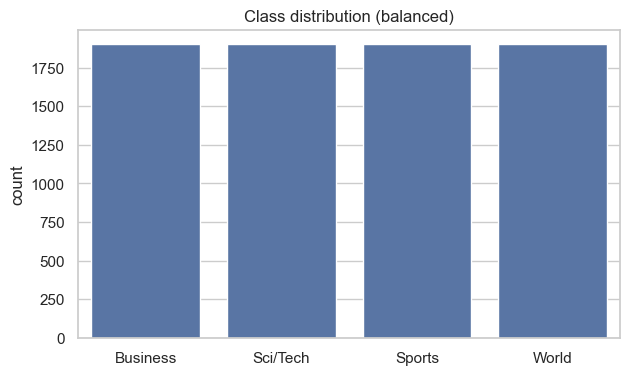

In [3]:
order = sorted(df["category"].unique())
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="category", order=order)
plt.title("Class distribution (balanced)")
plt.xlabel("")
plt.show()

## 2 · Exploratory analysis

### Text length
Most cleaned articles are short and dense — a good fit for TF-IDF without heavy padding.

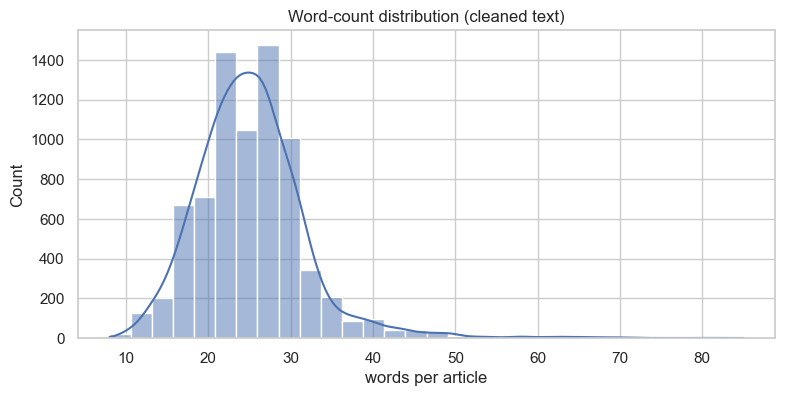

count    7600.000000
mean       25.169211
std         6.816745
min         8.000000
25%        21.000000
50%        25.000000
75%        29.000000
max        85.000000
Name: word_count, dtype: float64

In [4]:
df["word_count"] = df["text"].str.split().apply(len)
plt.figure(figsize=(9, 4))
sns.histplot(df["word_count"], bins=30, kde=True)
plt.title("Word-count distribution (cleaned text)")
plt.xlabel("words per article")
plt.show()
df["word_count"].describe()

### Most frequent words per class
Each topic has its own signature vocabulary — early evidence the classes are separable.

> *The original coursework had a copy-paste bug here that plotted Sports words for three of
> the four classes. Writing this as a single loop over `order` makes that error impossible.*

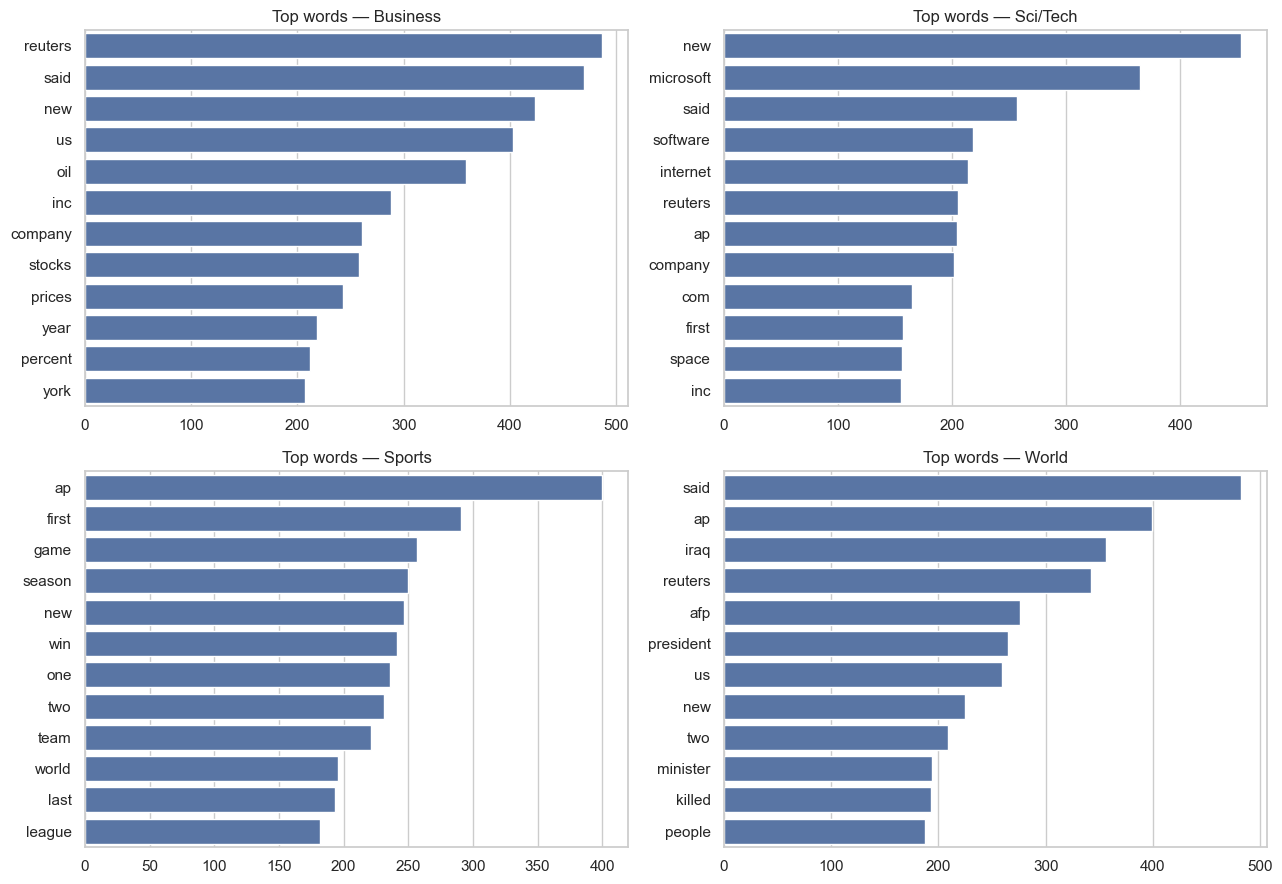

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, cat in zip(axes.flat, order):
    words = " ".join(df.loc[df["category"] == cat, "text"]).split()
    top_words, counts = zip(*Counter(words).most_common(12))
    sns.barplot(x=list(counts), y=list(top_words), ax=ax)
    ax.set_title(f"Top words — {cat}")
plt.tight_layout()
plt.show()

## 3 · Features — TF-IDF

TF-IDF turns each article into a numeric vector: a word scores high if it is frequent in
*this* article but rare across the corpus. **The vectorizer is fit on the training set only**,
so the test set never leaks into the IDF statistics.

In [6]:
X_train, X_test, y_train, y_test, vectorizer = build_features(df)
print("train:", X_train.shape, " test:", X_test.shape)
print("vocabulary size:", len(vectorizer.vocabulary_))

train: (6080, 19001)  test: (1520, 19001)
vocabulary size: 19001


## 4 · Three classic models

Naive Bayes, Logistic Regression, and Linear SVM — all scored on the **held-out test set**.

Naive Bayes            test accuracy = 0.8921


Logistic Regression    test accuracy = 0.8836
Linear SVM             test accuracy = 0.8796


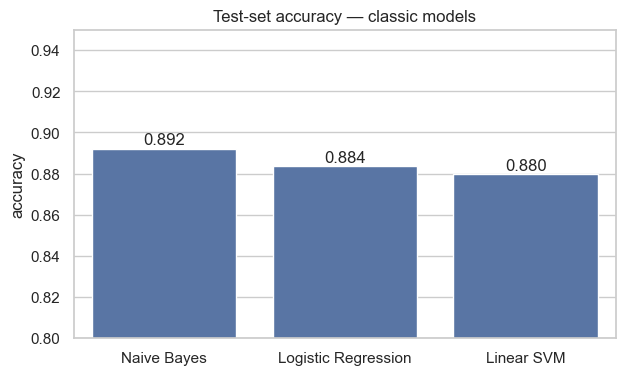

In [7]:
results = train_and_evaluate(X_train, X_test, y_train, y_test)

acc = {name: a for name, (model, a) in results.items()}
plt.figure(figsize=(7, 4))
ax = sns.barplot(x=list(acc.keys()), y=list(acc.values()))
ax.set_ylim(0.80, 0.95)
ax.set_title("Test-set accuracy — classic models")
ax.set_ylabel("accuracy")
for i, v in enumerate(acc.values()):
    ax.text(i, v + 0.002, f"{v:.3f}", ha="center")
plt.show()

## 5 · Best classic model in detail

Per-class precision / recall and a confusion matrix for the strongest model.

Best model: Naive Bayes  (test accuracy = 0.8921)

              precision    recall  f1-score   support

    Business       0.85      0.86      0.86       380
    Sci/Tech       0.89      0.85      0.87       380
      Sports       0.94      0.97      0.95       380
       World       0.89      0.89      0.89       380

    accuracy                           0.89      1520
   macro avg       0.89      0.89      0.89      1520
weighted avg       0.89      0.89      0.89      1520



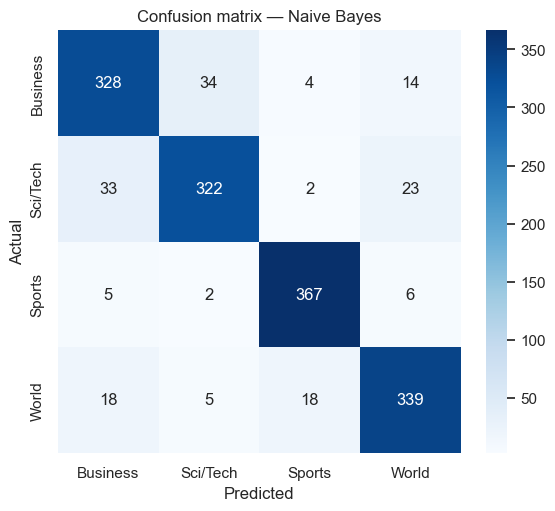

In [8]:
name, model, acc = best_model(results)
print(f"Best model: {name}  (test accuracy = {acc:.4f})\n")
y_pred, cm, labels = evaluate_model(model, X_test, y_test)

plt.figure(figsize=(6.5, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title(f"Confusion matrix — {name}")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

## 6 · What did the model learn?

Logistic Regression is interpretable: we can read off the words that most push an article
toward each class.

In [9]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000).fit(X_train, y_train)
feature_names = np.array(vectorizer.get_feature_names_out())
for i, cat in enumerate(clf.classes_):
    top = feature_names[np.argsort(clf.coef_[i])[::-1][:12]]
    print(f"{cat:10}: " + ", ".join(top))

Business  : oil, us, inc, bank, company, shares, prices, profit, billion, dollar, co, airlines
Sci/Tech  : space, microsoft, internet, software, scientists, technology, apple, users, linux, ibm, nasa, study
Sports    : season, cup, team, coach, win, league, football, olympic, victory, game, sports, night
World     : afp, iraq, president, minister, nuclear, killed, ap, arafat, people, troops, iraqi, baghdad


## 7 · Bonus — a neural network (PyTorch)

A different approach: instead of TF-IDF, learn a dense **embedding** for each word, average
the embeddings of an article, and classify with a small MLP (hidden layer + ReLU + dropout).

### Training loop
The model starts from random weights and learns by **gradient descent** — for each mini-batch
it (1) predicts, (2) measures the loss, (3) back-propagates to find which way to nudge each
weight, (4) takes a small step. One *epoch* = one full pass over the training data; it takes
many epochs of small steps to turn random weights into useful ones.

Same train/test split as the classic models (fair comparison); vocabulary built from the
**training set only**. Full implementation in [`src/neural_net.py`](../src/neural_net.py).

In [10]:
from neural_net import (build_vocab, encode_labels, make_loaders,
                        TextMLP, train_nn)
import torch
torch.manual_seed(42)

# 复用与 sklearn 完全相同的切分
text_train, text_test, ytr, yte = split_data(df)
yi_train, yi_test, nn_classes = encode_labels(ytr, yte)

vocab = build_vocab(text_train)                       # 词表只从训练集建
train_loader, test_loader = make_loaders(text_train, yi_train,
                                         text_test, yi_test, vocab)
print("vocab size:", len(vocab))

nn_model = TextMLP(len(vocab))
nn_model, history = train_nn(nn_model, train_loader, test_loader, epochs=15)
nn_test_acc = history["test_acc"][-1]

vocab size: 11322


epoch 1: train_acc=0.5324  test_acc=0.5118


epoch 2: train_acc=0.6954  test_acc=0.6520


epoch 3: train_acc=0.8132  test_acc=0.7447


epoch 4: train_acc=0.8615  test_acc=0.7829


...

epoch 11: train_acc=0.9720  test_acc=0.8303


epoch 12: train_acc=0.9786  test_acc=0.8263


epoch 13: train_acc=0.9827  test_acc=0.8309


epoch 14: train_acc=0.9857  test_acc=0.8303


epoch 15: train_acc=0.9882  test_acc=0.8303


### The overfitting gap
Train accuracy keeps climbing toward 100% (the model memorises the training set), but test
accuracy plateaus early. That gap **is** overfitting — and it is exactly what a single
"training accuracy" number (the original report's 96.76%) hides.

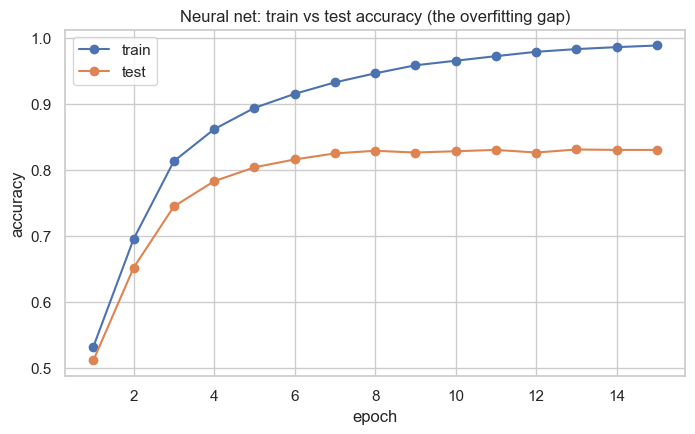

final neural-net TEST accuracy = 0.8303


In [11]:
epochs = range(1, len(history["train_acc"]) + 1)
plt.figure(figsize=(8, 4.5))
plt.plot(epochs, history["train_acc"], marker="o", label="train")
plt.plot(epochs, history["test_acc"], marker="o", label="test")
plt.title("Neural net: train vs test accuracy (the overfitting gap)")
plt.xlabel("epoch"); plt.ylabel("accuracy")
plt.legend()
plt.show()
print(f"final neural-net TEST accuracy = {nn_test_acc:.4f}")

## 8 · All models compared

The honest, like-for-like comparison on the same held-out test set.

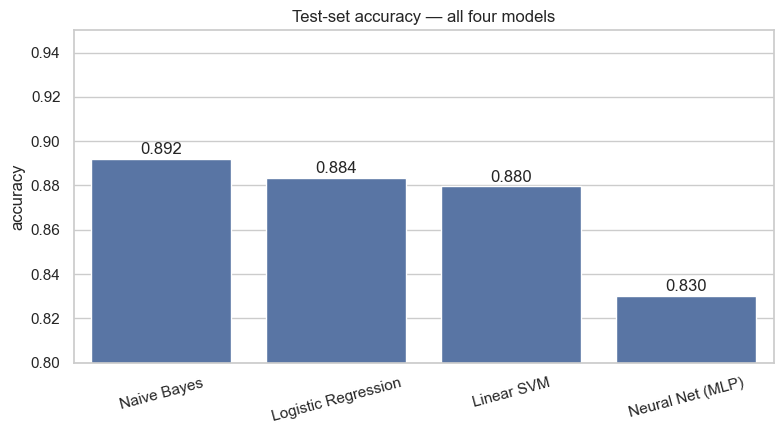

In [12]:
all_acc = {name: a for name, (m, a) in results.items()}
all_acc["Neural Net (MLP)"] = nn_test_acc

plt.figure(figsize=(8, 4.5))
ax = sns.barplot(x=list(all_acc.keys()), y=list(all_acc.values()))
ax.set_ylim(0.80, 0.95)
ax.set_title("Test-set accuracy — all four models")
ax.set_ylabel("accuracy")
for i, v in enumerate(all_acc.values()):
    ax.text(i, v + 0.002, f"{v:.3f}", ha="center")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 9 · Takeaways

- **Clean features matter most.** Once the text is properly cleaned, all three classic models
  land within ~1% of each other (~88–89%) — model choice is no longer the bottleneck.
- **Naive Bayes wins narrowly**, and a simple **Logistic Regression / Linear SVM** are right
  behind — and interpretable.
- **The neural network underperforms (~0.83)**, not because it is "worse", but because averaging
  learned embeddings discards signal that TF-IDF keeps, and 6k articles is too little to learn
  good embeddings from scratch. *Fancier ≠ better* — always benchmark against simple baselines.
- **Honest evaluation changes the story.** The original report's 96.76% was a *training* number;
  on the held-out test set the network sits well below the simple models.
- **Interpretability surfaces shortcuts.** The learned weights are sensible, but news-agency tags
  like *afp* / *ap* leak in as signal — a reminder to watch for spurious correlations.

**Where to go next:** pretrained embeddings (GloVe) or a transformer would likely lift the neural
model above the baselines — at much higher cost.